In [1]:
import sys
print(sys.executable)

C:\Users\sarab\Projects\CT4101 ML Project\Machine_Learning_Portfolio_Project\.venv\Scripts\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path
print(Path.cwd())
# Create data directory 
data_directory = Path("../data/raw")
print(list(data_directory.iterdir()))

C:\Users\sarab\Projects\CT4101 ML Project\Machine_Learning_Portfolio_Project\notebooks
[WindowsPath('../data/raw/S006.csv'), WindowsPath('../data/raw/S008.csv'), WindowsPath('../data/raw/S009.csv'), WindowsPath('../data/raw/S010.csv'), WindowsPath('../data/raw/S012.csv'), WindowsPath('../data/raw/S013.csv'), WindowsPath('../data/raw/S014.csv'), WindowsPath('../data/raw/S015.csv'), WindowsPath('../data/raw/S016.csv'), WindowsPath('../data/raw/S017.csv'), WindowsPath('../data/raw/S018.csv'), WindowsPath('../data/raw/S019.csv'), WindowsPath('../data/raw/S020.csv'), WindowsPath('../data/raw/S021.csv'), WindowsPath('../data/raw/S022.csv'), WindowsPath('../data/raw/S023.csv'), WindowsPath('../data/raw/S024.csv'), WindowsPath('../data/raw/S025.csv'), WindowsPath('../data/raw/S026.csv'), WindowsPath('../data/raw/S027.csv'), WindowsPath('../data/raw/S028.csv'), WindowsPath('../data/raw/S029.csv')]


In [4]:
# Read one csv file from the HARTH dataset 
df = pd.read_csv(data_directory / "S006.csv")

In [5]:
# Inspect 
print(df.shape)

(408709, 8)


In [6]:
print(df.head())

                 timestamp    back_x    back_y    back_z   thigh_x   thigh_y  \
0  2019-01-12 00:00:00.000 -0.760242  0.299570  0.468570 -5.092732 -0.298644   
1  2019-01-12 00:00:00.010 -0.530138  0.281880  0.319987  0.900547  0.286944   
2  2019-01-12 00:00:00.020 -1.170922  0.186353 -0.167010 -0.035442 -0.078423   
3  2019-01-12 00:00:00.030 -0.648772  0.016579 -0.054284 -1.554248 -0.950978   
4  2019-01-12 00:00:00.040 -0.355071 -0.051831 -0.113419 -0.547471  0.140903   

    thigh_z  label  
0  0.709439      6  
1  0.340309      6  
2 -0.515212      6  
3 -0.221140      6  
4 -0.653782      6  


In [7]:
print(df.sample(5, random_state=42))

                      timestamp    back_x    back_y    back_z   thigh_x  \
90448   2019-01-12 00:15:17.980 -0.921775 -0.171286 -0.324366 -0.309476   
251195  2019-01-12 00:42:49.420 -0.986820 -0.026993 -0.085336  0.204236   
333584  2019-01-12 00:56:51.960 -0.864463 -0.134194  0.250925 -1.045280   
209297  2019-01-12 00:35:49.400 -0.473979  0.036802 -0.879451  0.056024   
254703  2019-01-12 00:43:24.500 -0.980958  0.093409 -0.165118 -1.029133   

         thigh_y   thigh_z  label  
90448   0.263192  0.923418      7  
251195  0.116661  0.983130      7  
333584  0.154854  0.519347     13  
209297  0.022346  1.013913      7  
254703  0.053266 -0.213627      1  


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 408709 entries, 0 to 408708
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   timestamp  408709 non-null  str    
 1   back_x     408709 non-null  float64
 2   back_y     408709 non-null  float64
 3   back_z     408709 non-null  float64
 4   thigh_x    408709 non-null  float64
 5   thigh_y    408709 non-null  float64
 6   thigh_z    408709 non-null  float64
 7   label      408709 non-null  int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 24.9 MB


In [9]:
print(df.describe(include="all").T)

              count  unique                      top freq       mean  \
timestamp    408709  408709  2019-01-12 00:00:00.000    1        NaN   
back_x     408709.0     NaN                      NaN  NaN  -0.802201   
back_y     408709.0     NaN                      NaN  NaN  -0.000687   
back_z     408709.0     NaN                      NaN  NaN  -0.274718   
thigh_x    408709.0     NaN                      NaN  NaN  -0.370317   
thigh_y    408709.0     NaN                      NaN  NaN   0.143471   
thigh_z    408709.0     NaN                      NaN  NaN   0.617527   
label      408709.0     NaN                      NaN  NaN  10.190187   

                 std       min       25%       50%       75%       max  
timestamp        NaN       NaN       NaN       NaN       NaN       NaN  
back_x      0.238347 -3.542889 -0.983647 -0.937195 -0.654541  0.952109  
back_y      0.189062 -3.016498  0.001063   0.03324  0.074822  2.569339  
back_z      0.441805 -1.024363 -0.702338 -0.277446  0.06481

In [10]:
print(df.isna().mean().sort_values(ascending=False))

timestamp    0.0
back_x       0.0
back_y       0.0
back_z       0.0
thigh_x      0.0
thigh_y      0.0
thigh_z      0.0
label        0.0
dtype: float64


In [11]:
print(df.nunique().sort_values())

label            10
timestamp    408709
back_y       408709
back_x       408709
back_z       408709
thigh_x      408709
thigh_y      408709
thigh_z      408709
dtype: int64


In [12]:
print(df.duplicated().sum())

0


In [13]:
print(df["label"].value_counts())

label
7      253029
6       62682
13      25040
1       24889
8       13036
3       12693
130     11290
14       3130
5        1550
4        1370
Name: count, dtype: int64


In [14]:
# Change timestamp from object type to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(df.dtypes)
print(df["timestamp"].diff()) # difference in time between each row
print(df["timestamp"].duplicated().sum()) # number of duplicate rows

timestamp    datetime64[us]
back_x              float64
back_y              float64
back_z              float64
thigh_x             float64
thigh_y             float64
thigh_z             float64
label                 int64
dtype: object
0                           NaT
1        0 days 00:00:00.010000
2        0 days 00:00:00.010000
3        0 days 00:00:00.010000
4        0 days 00:00:00.010000
                  ...          
408704   0 days 00:00:00.010000
408705   0 days 00:00:00.010000
408706   0 days 00:00:00.010000
408707   0 days 00:00:00.010000
408708   0 days 00:00:00.010000
Name: timestamp, Length: 408709, dtype: timedelta64[us]
0


In [15]:
# Inspecting all csv files in the HARTH dataset

csv_files = sorted(data_directory.glob("*.csv"))
print(len(csv_files), "files found")

summaries = []
label_counts = {}

for file in csv_files:
    data = pd.read_csv(file)
    
    data["timestamp"] = pd.to_datetime(data["timestamp"]) # Convert to datetime
    time_between_rows = data["timestamp"].diff() # Time between each row
    step = time_between_rows.median() # Median time between 2 rows for a participant

    summaries.append({
        "Subject": file.stem,
        "No. of Rows": len(data),
        "Columns": list(data.columns),
        "No. of Missing Values": data.isna().sum().sum(), 
        "Duration": data["timestamp"].max() - data["timestamp"].min(), 
        "No. of Duplicate Timestamps": data["timestamp"].duplicated().sum(),
        "Steps >10ms": (time_between_rows > pd.Timedelta("10ms")).sum(), # Time between each row >10ms (like S006)
        "Steps >15ms": (time_between_rows > pd.Timedelta("15ms")).sum(), # Time between each row >15ms 
        "Steps >20ms": (time_between_rows > pd.Timedelta("20ms")).sum(), # Time between each row >20ms 
        "sample_step": step, # Since participants have different times between each row
        "Labels": sorted(data["label"].unique()),    
    })

    label_counts[file.stem] = data["label"].value_counts()* step.total_seconds() / 60 # Count per activity per participant in minutes

summary = pd.DataFrame(summaries)
summary

#summary.to_string()

22 files found


,Subject,No. of Rows,Columns,No. of Missing Values,Duration,No. of Duplicate Timestamps,Steps >10ms,Steps >15ms,Steps >20ms,sample_step,Labels
0,S006,408709,"[timestamp, back_x, back_y, back_z, thigh_x, t...",0,0 days 01:09:32.920000,0,38,38,38,0 days 00:00:00.010000,"[1, 3, 4, 5, 6, 7, 8, 13, 14, 130]"
1,S008,418989,"[timestamp, back_x, back_y, back_z, thigh_x, t...",0,0 days 02:23:36.720000,0,418988,418988,38,0 days 00:00:00.020000,"[1, 3, 4, 5, 6, 7, 13, 14, 130, 140]"
2,S009,154464,"[timestamp, back_x, back_y, back_z, thigh_x, t...",0,0 days 00:51:41.820000,0,154463,154463,6,0 days 00:00:00.020000,"[1, 3, 4, 5, 6, 13, 14, 130, 140]"
3,S010,351649,"[timestamp, back_x, back_y, back_z, thigh_x, t...",0,0 days 02:02:49.560000,0,351648,351648,13,0 days 00:00:00.020000,"[1, 3, 4, 5, 6, 7]"
4,S012,382414,"[timestamp, back_x, back_y, back_z, thigh_x, t...",0,0 days 02:08:44.660000,0,382413,382413,32,0 days 00:00:00.020000,"[1, 2, 3, 4, 5, 6, 7, 8]"
5,S013,369077,"[timestamp, back_x, back_y, back_z, thigh_x, t...",0,0 days 02:08:57.520000,0,369076,369076,54,0 days 00:00:00.020000,"[1, 2, 3, 4, 5, 6, 7, 8, 13, 130]"
6,S014,366487,"[timestamp, back_x, back_y, back_z, thigh_x, t...",0,0 days 02:09:26.960000,0,366486,366486,69,0 days 00:00:00.020000,"[1, 2, 3, 4, 5, 6, 7, 8, 13]"
7,S015,418392,"[timestamp, index, back_x, back_y, back_z, thi...",0,0 days 02:21:23.460000,0,418391,418391,36,0 days 00:00:00.020000,"[1, 2, 3, 4, 5, 6, 7, 8, 13, 14]"
8,S016,355418,"[timestamp, back_x, back_y, back_z, thigh_x, t...",0,0 days 02:02:11.940000,0,355417,355417,35,0 days 00:00:00.020000,"[1, 2, 3, 4, 5, 6, 7, 8, 13, 14, 130]"
9,S017,366609,"[timestamp, back_x, back_y, back_z, thigh_x, t...",0,0 days 02:04:25.720000,0,366608,366608,38,0 days 00:00:00.020000,"[1, 2, 3, 4, 5, 6, 7, 8, 13, 14, 130, 140]"


In [16]:
# Checking which Subjects have extra columns
summary["Columns"].astype(str).value_counts()

Columns
['timestamp', 'back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z', 'label']                  19
['timestamp', 'index', 'back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z', 'label']          2
['Unnamed: 0', 'timestamp', 'back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z', 'label']     1
Name: count, dtype: int64

In [29]:
# Total number of rows 
sum(summary["No. of Rows"])

6461328


In [17]:
# Table for activity count (in minutes)
label_table = pd.DataFrame(label_counts).T.fillna(0).round(2)
# Rename columns as activity names
label_table = label_table.sort_index(axis=1).rename(columns={1: "walking", 2: "running", 3: "shuffling", 4: "stairs (ascending)",
                                          5: "stairs (descending)", 6: "standing", 7: "sitting", 8: "lying",
                                          13: "cycling (sit)", 14: "cycling (stand)", 130: "cycling (sit, inactive)",
                                          140: "cycling (stand, inactive)"})
label_table

label,walking,running,shuffling,stairs (ascending),stairs (descending),standing,sitting,lying,cycling (sit),cycling (stand),"cycling (sit, inactive)","cycling (stand, inactive)"
S006,4.15,0.00,2.12,0.23,0.26,10.45,42.17,2.17,4.17,0.52,1.88,0.00
S008,7.15,0.00,9.61,0.24,0.25,21.74,97.60,0.00,2.52,0.25,0.06,0.25
S009,1.89,0.00,0.06,0.15,0.19,2.03,0.00,0.00,40.03,3.64,3.46,0.04
S010,58.64,0.00,9.91,1.99,1.14,30.06,15.48,0.00,0.00,0.00,0.00,0.00
S012,4.32,0.73,2.40,1.44,0.92,7.45,103.91,6.30,0.00,0.00,0.00,0.00
S013,11.52,1.16,12.44,1.15,0.95,17.86,74.47,2.52,0.92,0.00,0.03,0.00
S014,9.36,0.83,6.17,1.69,1.48,18.78,78.86,3.14,1.86,0.00,0.00,0.00
S015,18.34,0.98,4.00,2.36,2.21,22.43,65.01,21.11,2.42,0.60,0.00,0.00
S016,13.10,0.94,5.67,0.11,0.80,17.61,63.27,13.32,3.49,0.10,0.08,0.00
S017,11.98,1.71,3.12,2.72,2.03,10.32,72.63,14.69,1.56,1.03,0.35,0.05


In [21]:
#Total count per activity in minutes
total_label_minutes = label_table.sum().sort_values(ascending=False)
total_label_minutes

label
sitting                      925.37
walking                      394.91
standing                     237.37
lying                        140.79
cycling (sit)                127.14
running                       97.09
shuffling                     82.82
stairs (ascending)            25.20
stairs (descending)           22.16
cycling (stand)               18.09
cycling (sit, inactive)       12.04
cycling (stand, inactive)      2.62
dtype: float64

In [31]:
#Total hours
print(sum(total_label_minutes)/60)

#total seconds
print(sum(total_label_minutes)*60)

34.76
125136.0


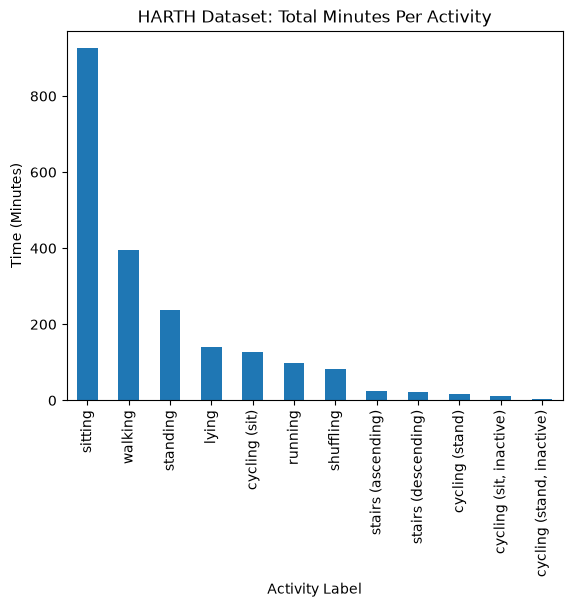

In [19]:
# Bar chart
plot = total_label_minutes.plot(kind="bar")
plot.set_xlabel("Activity Label")
plot.set_ylabel("Time (Minutes)")
plot.set_title("HARTH Dataset: Total Minutes Per Activity")
plt.show()

#### Activity coding
- 1: walking	
- 2: running	
- 3: shuffling
- 4: stairs (ascending)	
- 5: stairs (descending)	
- 6: standing	
- 7: sitting	
- 8: lying	
- 13: cycling (sit)	
- 14: cycling (stand)	
- 130: cycling (sit, inactive)
- 140: cycling (stand, inactive)